# [5.1] Gemma from Scratch - Solutions

**Core question:** can seven transparent Gemma primitives reproduce an independent reference decoder at every residual-stream stage, not merely return a tensor of the right shape?

**Claim.** With identical deterministic weights, the completed model will match the independent reference exactly across embeddings, both decoder blocks, final normalization, and logits. Three deliberate architecture mistakes will diverge at the stage where their missing convention first matters.

## Learning objectives

By the end of this notebook, you will be able to:

- implement Gemma RMSNorm, interleaved RoPE, grouped-query attention, SwiGLU, and cache-aware masking;
- assemble those primitives into a complete two-layer causal language model;
- test full-context and cached decoding semantically;
- trace activations and localize the first mismatch against a reference;
- distinguish architecture parity with deterministic weights from pretrained language-model validation.

<img src="../../instructions/assets/gemma_decoder_block.svg" width="760">

## Cold open: one exact target

We use a two-layer, width-16 Gemma model organism with vocabulary size 31. The token IDs are generated test inputs, and the weights come from seed `5101`. This organism has no language ability; its role is exact ground truth. It is large enough for every architectural convention to affect real logits and small enough to run every cell on CPU.

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch as t
import torch.nn as nn
import torch.nn.functional as F

chapter = "chapter5_modern_architectures"
section = "part1_gemma_from_scratch"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
assets_dir = root_dir / chapter / "instructions" / "assets"
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part1_gemma_from_scratch.tests as tests

from arena_ext.gemma import (
    GemmaCausalLMOutput,
    GemmaConfig,
    GemmaForCausalLM as ReferenceGemmaForCausalLM,
)

DEVICE = t.device("cpu")
PastKeyValue = tuple[t.Tensor, t.Tensor]

In [2]:
SIGNATURE_INPUT_IDS = t.tensor(
    [
        [1, 5, 8, 13, 2, 21, 3],
        [3, 2, 1, 8, 5, 13, 21],
        [21, 13, 8, 5, 3, 2, 1],
        [2, 3, 5, 8, 13, 21, 1],
    ],
    dtype=t.long,
    device=DEVICE,
)
cold_config = GemmaConfig(
    vocab_size=31,
    hidden_size=16,
    intermediate_size=32,
    num_hidden_layers=2,
    num_attention_heads=4,
    num_key_value_heads=2,
    max_position_embeddings=64,
)
t.manual_seed(5101)
cold_reference = ReferenceGemmaForCausalLM(cold_config).eval()
with t.inference_mode():
    cold_logits = cold_reference(SIGNATURE_INPUT_IDS).logits
print("logits shape:", tuple(cold_logits.shape))
print("last-position argmax token ids:", cold_logits[:, -1].argmax(dim=-1).tolist())

logits shape: (4, 7, 31)
last-position argmax token ids: [3, 21, 1, 1]


<details><summary>Expected output</summary>

```text
logits shape: (4, 7, 31)
last-position argmax token ids: [3, 21, 1, 1]
```

</details>

The output is intentionally concrete: by the end, your own model must reproduce all `4 x 7 x 31` logits, not just these four argmax IDs.

## Build the primitives

### Exercise - implement Gemma RMSNorm

> **Difficulty:** medium  
> **Suggested time:** 10-15 minutes

Normalize each residual vector by its root mean square, then apply Gemma's learned offset scale `1 + weight`. Keep the computation in float32 and cast back to the input dtype.

<details><summary>Expected output</summary>

```text
All tests in `test_gemma_rms_norm` passed!
```

</details>

<details><summary>Help</summary>

Do not subtract the mean. Compute `mean(x**2)` only over the hidden dimension. A zero-initialized weight must leave the normalized vector at unit scale.

</details>

<details><summary>Interpretation</summary>

A LayerNorm-shaped implementation can pass every shape check while rotating the residual direction. Reference parity catches that semantic error.

</details>

<details><summary>Solution</summary>

```python
class GemmaRMSNorm(nn.Module):
    def __init__(self, hidden_size: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(t.zeros(hidden_size))
        self.eps = eps

    def forward(self, x: t.Tensor) -> t.Tensor:
        dtype = x.dtype
        x_float = x.float()
        rms = x_float.pow(2).mean(dim=-1, keepdim=True)
        normalized = x_float * t.rsqrt(rms + self.eps)
        return (normalized * (1.0 + self.weight.float())).to(dtype)
```

</details>

In [3]:
class GemmaRMSNorm(nn.Module):
    def __init__(self, hidden_size: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(t.zeros(hidden_size))
        self.eps = eps

    def forward(self, x: t.Tensor) -> t.Tensor:
        dtype = x.dtype
        x_float = x.float()
        rms = x_float.pow(2).mean(dim=-1, keepdim=True)
        normalized = x_float * t.rsqrt(rms + self.eps)
        return (normalized * (1.0 + self.weight.float())).to(dtype)



tests.test_gemma_rms_norm(GemmaRMSNorm)

All tests in `test_gemma_rms_norm` passed!


### Exercise - implement interleaved RoPE

> **Difficulty:** hard  
> **Suggested time:** 20-25 minutes

Implement the quarter-turn helper, build the cosine/sine cache, and apply position-indexed rotations to tensors shaped `[batch, heads, seq, head_dim]`.

<details><summary>Expected output</summary>

```text
All tests in `test_rotate_half_interleaved` passed!
All tests in `test_build_rope_cache` passed!
All tests in `test_apply_rope` passed!
```

</details>

<details><summary>Help</summary>

After indexing the cache with `position_ids`, insert the head axis with `unsqueeze(1)`. Position zero must be the identity and every head-vector norm must be preserved.

</details>

<details><summary>Interpretation</summary>

Norm preservation is necessary but insufficient: swapping the pair layout can preserve norms and still change every attention score. Later layer parity detects that error.

</details>

<details><summary>Solution</summary>

```python
def rotate_half_interleaved(x: t.Tensor) -> t.Tensor:
    x_even = x[..., 0::2]
    x_odd = x[..., 1::2]
    return t.stack((-x_odd, x_even), dim=-1).flatten(start_dim=-2)


def build_rope_cache(
    seq_len: int,
    head_dim: int,
    *,
    base: float,
    device: t.device,
    dtype: t.dtype,
) -> tuple[t.Tensor, t.Tensor]:
    inv_freq = 1.0 / (base ** (t.arange(0, head_dim, 2, device=device).float() / head_dim))
    positions = t.arange(seq_len, device=device).float()
    freqs = t.outer(positions, inv_freq)
    angles = t.repeat_interleave(freqs, repeats=2, dim=-1)
    return angles.cos().to(dtype), angles.sin().to(dtype)


def apply_rope(
    x: t.Tensor,
    cos: t.Tensor,
    sin: t.Tensor,
    position_ids: t.Tensor,
) -> t.Tensor:
    cos_at_position = cos[position_ids].unsqueeze(1)
    sin_at_position = sin[position_ids].unsqueeze(1)
    return (x * cos_at_position) + (rotate_half_interleaved(x) * sin_at_position)
```

</details>

In [4]:
def rotate_half_interleaved(x: t.Tensor) -> t.Tensor:
    x_even = x[..., 0::2]
    x_odd = x[..., 1::2]
    return t.stack((-x_odd, x_even), dim=-1).flatten(start_dim=-2)


def build_rope_cache(
    seq_len: int,
    head_dim: int,
    *,
    base: float,
    device: t.device,
    dtype: t.dtype,
) -> tuple[t.Tensor, t.Tensor]:
    inv_freq = 1.0 / (base ** (t.arange(0, head_dim, 2, device=device).float() / head_dim))
    positions = t.arange(seq_len, device=device).float()
    freqs = t.outer(positions, inv_freq)
    angles = t.repeat_interleave(freqs, repeats=2, dim=-1)
    return angles.cos().to(dtype), angles.sin().to(dtype)


def apply_rope(
    x: t.Tensor,
    cos: t.Tensor,
    sin: t.Tensor,
    position_ids: t.Tensor,
) -> t.Tensor:
    cos_at_position = cos[position_ids].unsqueeze(1)
    sin_at_position = sin[position_ids].unsqueeze(1)
    return (x * cos_at_position) + (rotate_half_interleaved(x) * sin_at_position)



tests.test_rotate_half_interleaved(rotate_half_interleaved)
tests.test_build_rope_cache(build_rope_cache)
tests.test_apply_rope(apply_rope, build_rope_cache)

All tests in `test_rotate_half_interleaved` passed!
All tests in `test_build_rope_cache` passed!
All tests in `test_apply_rope` passed!


### Exercise - repeat KV heads and build a cache-aware mask

> **Difficulty:** hard  
> **Suggested time:** 20-25 minutes

Repeat each key/value head contiguously for its query-head group. Then construct a boolean causal mask from absolute query positions, including an optional sliding window.

<details><summary>Expected output</summary>

```text
All tests in `test_repeat_kv` passed!
All tests in `test_sliding_window_mask` passed!
```

</details>

<details><summary>Help</summary>

For cached decoding, queries begin at `past_length`; they do not restart at zero. For two KV heads repeated twice, the head order is `[K0, K0, K1, K1]`.

</details>

<details><summary>Interpretation</summary>

The mask test uses cached queries at absolute positions 3 and 4. It therefore catches implementations that only work for an uncached square attention matrix.

</details>

<details><summary>Solution</summary>

```python
def repeat_kv(hidden_states: t.Tensor, repeats: int) -> t.Tensor:
    if repeats == 1:
        return hidden_states
    batch, kv_heads, seq_len, head_dim = hidden_states.shape
    hidden_states = hidden_states[:, :, None, :, :].expand(
        batch, kv_heads, repeats, seq_len, head_dim
    )
    return hidden_states.reshape(batch, kv_heads * repeats, seq_len, head_dim)


def build_causal_attention_mask(
    *,
    query_length: int,
    key_length: int,
    past_length: int,
    sliding_window: int | None,
    device: t.device,
) -> t.Tensor:
    query_positions = t.arange(past_length, past_length + query_length, device=device)[:, None]
    key_positions = t.arange(key_length, device=device)[None, :]
    allowed = key_positions <= query_positions
    if sliding_window is not None:
        allowed = allowed & (key_positions >= query_positions - sliding_window + 1)
    return allowed[None, None, :, :]
```

</details>

In [5]:
def repeat_kv(hidden_states: t.Tensor, repeats: int) -> t.Tensor:
    if repeats == 1:
        return hidden_states
    batch, kv_heads, seq_len, head_dim = hidden_states.shape
    hidden_states = hidden_states[:, :, None, :, :].expand(
        batch, kv_heads, repeats, seq_len, head_dim
    )
    return hidden_states.reshape(batch, kv_heads * repeats, seq_len, head_dim)


def build_causal_attention_mask(
    *,
    query_length: int,
    key_length: int,
    past_length: int,
    sliding_window: int | None,
    device: t.device,
) -> t.Tensor:
    query_positions = t.arange(past_length, past_length + query_length, device=device)[:, None]
    key_positions = t.arange(key_length, device=device)[None, :]
    allowed = key_positions <= query_positions
    if sliding_window is not None:
        allowed = allowed & (key_positions >= query_positions - sliding_window + 1)
    return allowed[None, None, :, :]



tests.test_repeat_kv(repeat_kv)
tests.test_sliding_window_mask(build_causal_attention_mask)

All tests in `test_repeat_kv` passed!
All tests in `test_sliding_window_mask` passed!


### Exercise - implement the SwiGLU MLP

> **Difficulty:** easy  
> **Suggested time:** 5-10 minutes

Pass one projection through SiLU, multiply it elementwise by the second projection, and project the gated activation back to the residual width.

<details><summary>Expected output</summary>

```text
All tests in `test_gemma_mlp_matches_swiglu_formula` passed!
```

</details>

<details><summary>Help</summary>

The order is `down_proj(silu(gate_proj(x)) * up_proj(x))`. There is no additive merge between the two wide projections.

</details>

<details><summary>Interpretation</summary>

The gate changes which intermediate features survive before the down projection. A plain SiLU MLP has the same output shape but represents a different architecture.

</details>

<details><summary>Solution</summary>

```python
class GemmaMLP(nn.Module):
    def __init__(self, config: GemmaConfig):
        super().__init__()
        self.gate_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.up_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.down_proj = nn.Linear(config.intermediate_size, config.hidden_size, bias=False)

    def forward(self, x: t.Tensor) -> t.Tensor:
        gated = F.silu(self.gate_proj(x)) * self.up_proj(x)
        return self.down_proj(gated)
```

</details>

In [6]:
class GemmaMLP(nn.Module):
    def __init__(self, config: GemmaConfig):
        super().__init__()
        self.gate_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.up_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.down_proj = nn.Linear(config.intermediate_size, config.hidden_size, bias=False)

    def forward(self, x: t.Tensor) -> t.Tensor:
        gated = F.silu(self.gate_proj(x)) * self.up_proj(x)
        return self.down_proj(gated)



tests.test_gemma_mlp_matches_swiglu_formula(GemmaMLP)

All tests in `test_gemma_mlp_matches_swiglu_formula` passed!


### Exercise - implement grouped-query attention with a KV cache

> **Difficulty:** hard  
> **Suggested time:** 35-45 minutes

Project and reshape Q/K/V, apply RoPE to queries and keys, append cached K/V states, repeat KV heads, mask attention scores, and merge query heads through the output projection.

<details><summary>Expected output</summary>

```text
All tests in `test_gemma_attention_shapes_and_cache` passed!
```

</details>

<details><summary>Help</summary>

Keep the un-repeated key/value tensors in the cache. Repeat only after appending the cache. Softmax in float32, then cast probabilities back to the query dtype.

</details>

<details><summary>Interpretation</summary>

A correct one-token cached step increases the cache length by one while returning one output position. This tests dataflow, not only tensor shape.

</details>

<details><summary>Solution</summary>

```python
class GemmaAttention(nn.Module):
    def __init__(self, config: GemmaConfig, layer_idx: int):
        super().__init__()
        self.config = config
        self.layer_idx = layer_idx
        self.num_heads = config.num_attention_heads
        self.num_key_value_heads = config.num_key_value_heads
        self.head_dim = config.head_dim
        self.num_key_value_groups = self.num_heads // self.num_key_value_heads
        self.q_proj = nn.Linear(config.hidden_size, self.num_heads * self.head_dim, bias=config.attention_bias)
        self.k_proj = nn.Linear(config.hidden_size, self.num_key_value_heads * self.head_dim, bias=config.attention_bias)
        self.v_proj = nn.Linear(config.hidden_size, self.num_key_value_heads * self.head_dim, bias=config.attention_bias)
        self.o_proj = nn.Linear(self.num_heads * self.head_dim, config.hidden_size, bias=config.attention_bias)

    def _shape(self, x: t.Tensor, heads: int) -> t.Tensor:
        batch, seq_len, _ = x.shape
        return x.view(batch, seq_len, heads, self.head_dim).transpose(1, 2).contiguous()

    def forward(
        self,
        hidden_states: t.Tensor,
        *,
        position_ids: t.Tensor,
        cos: t.Tensor,
        sin: t.Tensor,
        attention_mask: t.Tensor | None = None,
        past_key_value: PastKeyValue | None = None,
        use_cache: bool = False,
    ) -> tuple[t.Tensor, PastKeyValue | None]:
        batch, query_length, _ = hidden_states.shape
        query_states = self._shape(self.q_proj(hidden_states), self.num_heads)
        key_states = self._shape(self.k_proj(hidden_states), self.num_key_value_heads)
        value_states = self._shape(self.v_proj(hidden_states), self.num_key_value_heads)
        query_states = apply_rope(query_states, cos, sin, position_ids)
        key_states = apply_rope(key_states, cos, sin, position_ids)

        past_length = 0
        if past_key_value is not None:
            past_key, past_value = past_key_value
            past_length = past_key.shape[-2]
            key_states = t.cat([past_key, key_states], dim=-2)
            value_states = t.cat([past_value, value_states], dim=-2)
        present_key_value = (key_states, value_states) if use_cache else None

        key_length = key_states.shape[-2]
        key_states = repeat_kv(key_states, self.num_key_value_groups)
        value_states = repeat_kv(value_states, self.num_key_value_groups)
        attn_scores = query_states @ key_states.transpose(-1, -2)
        attn_scores = attn_scores / math.sqrt(self.head_dim)
        causal_mask = build_causal_attention_mask(
            query_length=query_length,
            key_length=key_length,
            past_length=past_length,
            sliding_window=self.config.sliding_window,
            device=hidden_states.device,
        )
        attn_scores = attn_scores.masked_fill(~causal_mask, t.finfo(attn_scores.dtype).min)
        if attention_mask is not None:
            if attention_mask.shape != (batch, key_length):
                raise ValueError(f"attention_mask has shape {tuple(attention_mask.shape)}, expected {(batch, key_length)}")
            attn_scores = attn_scores.masked_fill(
                ~attention_mask[:, None, None, :].bool(),
                t.finfo(attn_scores.dtype).min,
            )
        attn_probs = F.softmax(attn_scores.float(), dim=-1).to(query_states.dtype)
        attn_output = attn_probs @ value_states
        attn_output = attn_output.transpose(1, 2).reshape(
            batch, query_length, self.num_heads * self.head_dim
        )
        return self.o_proj(attn_output), present_key_value
```

</details>

In [7]:
class GemmaAttention(nn.Module):
    def __init__(self, config: GemmaConfig, layer_idx: int):
        super().__init__()
        self.config = config
        self.layer_idx = layer_idx
        self.num_heads = config.num_attention_heads
        self.num_key_value_heads = config.num_key_value_heads
        self.head_dim = config.head_dim
        self.num_key_value_groups = self.num_heads // self.num_key_value_heads
        self.q_proj = nn.Linear(config.hidden_size, self.num_heads * self.head_dim, bias=config.attention_bias)
        self.k_proj = nn.Linear(config.hidden_size, self.num_key_value_heads * self.head_dim, bias=config.attention_bias)
        self.v_proj = nn.Linear(config.hidden_size, self.num_key_value_heads * self.head_dim, bias=config.attention_bias)
        self.o_proj = nn.Linear(self.num_heads * self.head_dim, config.hidden_size, bias=config.attention_bias)

    def _shape(self, x: t.Tensor, heads: int) -> t.Tensor:
        batch, seq_len, _ = x.shape
        return x.view(batch, seq_len, heads, self.head_dim).transpose(1, 2).contiguous()

    def forward(
        self,
        hidden_states: t.Tensor,
        *,
        position_ids: t.Tensor,
        cos: t.Tensor,
        sin: t.Tensor,
        attention_mask: t.Tensor | None = None,
        past_key_value: PastKeyValue | None = None,
        use_cache: bool = False,
    ) -> tuple[t.Tensor, PastKeyValue | None]:
        batch, query_length, _ = hidden_states.shape
        query_states = self._shape(self.q_proj(hidden_states), self.num_heads)
        key_states = self._shape(self.k_proj(hidden_states), self.num_key_value_heads)
        value_states = self._shape(self.v_proj(hidden_states), self.num_key_value_heads)
        query_states = apply_rope(query_states, cos, sin, position_ids)
        key_states = apply_rope(key_states, cos, sin, position_ids)

        past_length = 0
        if past_key_value is not None:
            past_key, past_value = past_key_value
            past_length = past_key.shape[-2]
            key_states = t.cat([past_key, key_states], dim=-2)
            value_states = t.cat([past_value, value_states], dim=-2)
        present_key_value = (key_states, value_states) if use_cache else None

        key_length = key_states.shape[-2]
        key_states = repeat_kv(key_states, self.num_key_value_groups)
        value_states = repeat_kv(value_states, self.num_key_value_groups)
        attn_scores = query_states @ key_states.transpose(-1, -2)
        attn_scores = attn_scores / math.sqrt(self.head_dim)
        causal_mask = build_causal_attention_mask(
            query_length=query_length,
            key_length=key_length,
            past_length=past_length,
            sliding_window=self.config.sliding_window,
            device=hidden_states.device,
        )
        attn_scores = attn_scores.masked_fill(~causal_mask, t.finfo(attn_scores.dtype).min)
        if attention_mask is not None:
            if attention_mask.shape != (batch, key_length):
                raise ValueError(f"attention_mask has shape {tuple(attention_mask.shape)}, expected {(batch, key_length)}")
            attn_scores = attn_scores.masked_fill(
                ~attention_mask[:, None, None, :].bool(),
                t.finfo(attn_scores.dtype).min,
            )
        attn_probs = F.softmax(attn_scores.float(), dim=-1).to(query_states.dtype)
        attn_output = attn_probs @ value_states
        attn_output = attn_output.transpose(1, 2).reshape(
            batch, query_length, self.num_heads * self.head_dim
        )
        return self.o_proj(attn_output), present_key_value



tests.test_gemma_attention_shapes_and_cache(GemmaAttention)

All tests in `test_gemma_attention_shapes_and_cache` passed!


### Exercise - assemble one decoder layer

> **Difficulty:** medium  
> **Suggested time:** 15-20 minutes

Build a pre-norm attention residual update followed by a pre-norm SwiGLU residual update. Propagate the attention cache unchanged.

<details><summary>Expected output</summary>

```text
All tests in `test_gemma_decoder_layer_shapes_and_cache` passed!
```

</details>

<details><summary>Help</summary>

Save the residual before each sublayer. Normalize only the branch input; add the branch output back to the unnormalized residual.

</details>

<details><summary>Interpretation</summary>

The two normalization modules have separate learned scales. Reusing one module would tie parameters and break state-dict parity.

</details>

<details><summary>Solution</summary>

```python
class GemmaDecoderLayer(nn.Module):
    def __init__(self, config: GemmaConfig, layer_idx: int):
        super().__init__()
        self.self_attn = GemmaAttention(config, layer_idx=layer_idx)
        self.mlp = GemmaMLP(config)
        self.input_layernorm = GemmaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)
        self.post_attention_layernorm = GemmaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

    def forward(
        self,
        hidden_states: t.Tensor,
        *,
        position_ids: t.Tensor,
        cos: t.Tensor,
        sin: t.Tensor,
        attention_mask: t.Tensor | None = None,
        past_key_value: PastKeyValue | None = None,
        use_cache: bool = False,
    ) -> tuple[t.Tensor, PastKeyValue | None]:
        residual = hidden_states
        attn_output, present_key_value = self.self_attn(
            self.input_layernorm(hidden_states),
            position_ids=position_ids,
            cos=cos,
            sin=sin,
            attention_mask=attention_mask,
            past_key_value=past_key_value,
            use_cache=use_cache,
        )
        hidden_states = residual + attn_output
        residual = hidden_states
        hidden_states = residual + self.mlp(self.post_attention_layernorm(hidden_states))
        return hidden_states, present_key_value
```

</details>

In [8]:
class GemmaDecoderLayer(nn.Module):
    def __init__(self, config: GemmaConfig, layer_idx: int):
        super().__init__()
        self.self_attn = GemmaAttention(config, layer_idx=layer_idx)
        self.mlp = GemmaMLP(config)
        self.input_layernorm = GemmaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)
        self.post_attention_layernorm = GemmaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

    def forward(
        self,
        hidden_states: t.Tensor,
        *,
        position_ids: t.Tensor,
        cos: t.Tensor,
        sin: t.Tensor,
        attention_mask: t.Tensor | None = None,
        past_key_value: PastKeyValue | None = None,
        use_cache: bool = False,
    ) -> tuple[t.Tensor, PastKeyValue | None]:
        residual = hidden_states
        attn_output, present_key_value = self.self_attn(
            self.input_layernorm(hidden_states),
            position_ids=position_ids,
            cos=cos,
            sin=sin,
            attention_mask=attention_mask,
            past_key_value=past_key_value,
            use_cache=use_cache,
        )
        hidden_states = residual + attn_output
        residual = hidden_states
        hidden_states = residual + self.mlp(self.post_attention_layernorm(hidden_states))
        return hidden_states, present_key_value



tests.test_gemma_decoder_layer_shapes_and_cache(GemmaDecoderLayer)

All tests in `test_gemma_decoder_layer_shapes_and_cache` passed!


### Exercise - build the complete causal LM

> **Difficulty:** hard  
> **Suggested time:** 35-45 minutes

Create absolute positions, build one RoPE cache per forward pass, scale token embeddings by `sqrt(hidden_size)`, run both blocks, apply the final norm, and tie the LM head to the embedding matrix.

<details><summary>Expected output</summary>

```text
All tests in `test_tiny_gemma_forward_shape` passed!
All tests in `test_tiny_gemma_cache_parity` passed!
All tests in `test_tiny_gemma_matches_reference_decoder` passed!
```

</details>

<details><summary>Help</summary>

When a cache is supplied, extend a one-token attention mask with an all-ones prefix for cached keys. The embedding scale occurs before the first block. Weight tying assigns the same `Parameter`, not a copied tensor.

</details>

<details><summary>Interpretation</summary>

This is the first end-to-end semantic checkpoint. It simultaneously tests logits, tied weights, absolute positions, and cached decoding against an independent implementation.

</details>

<details><summary>Solution</summary>

```python
class GemmaModel(nn.Module):
    def __init__(self, config: GemmaConfig):
        super().__init__()
        self.config = config
        self.embed_tokens = nn.Embedding(config.vocab_size, config.hidden_size)
        self.layers = nn.ModuleList(
            [GemmaDecoderLayer(config, layer_idx=i) for i in range(config.num_hidden_layers)]
        )
        self.norm = GemmaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

    def forward(
        self,
        input_ids: t.Tensor,
        *,
        attention_mask: t.Tensor | None = None,
        past_key_values: tuple[PastKeyValue, ...] | None = None,
        use_cache: bool = False,
    ) -> tuple[t.Tensor, tuple[PastKeyValue, ...] | None]:
        batch, seq_len = input_ids.shape
        past_length = 0 if past_key_values is None else past_key_values[0][0].shape[-2]
        position_ids = t.arange(
            past_length, past_length + seq_len, device=input_ids.device
        ).unsqueeze(0).expand(batch, -1)
        cos, sin = build_rope_cache(
            past_length + seq_len,
            self.config.head_dim,
            base=self.config.rope_theta,
            device=input_ids.device,
            dtype=self.embed_tokens.weight.dtype,
        )
        if attention_mask is not None and past_length > 0 and attention_mask.shape[-1] == seq_len:
            prefix = t.ones(batch, past_length, dtype=attention_mask.dtype, device=attention_mask.device)
            attention_mask = t.cat([prefix, attention_mask], dim=-1)

        hidden_states = self.embed_tokens(input_ids) * math.sqrt(self.config.hidden_size)
        next_cache = [] if use_cache else None
        for layer_idx, layer in enumerate(self.layers):
            past_key_value = None if past_key_values is None else past_key_values[layer_idx]
            hidden_states, present = layer(
                hidden_states,
                position_ids=position_ids,
                cos=cos,
                sin=sin,
                attention_mask=attention_mask,
                past_key_value=past_key_value,
                use_cache=use_cache,
            )
            if use_cache:
                assert next_cache is not None and present is not None
                next_cache.append(present)
        return self.norm(hidden_states), None if next_cache is None else tuple(next_cache)


class GemmaForCausalLM(nn.Module):
    def __init__(self, config: GemmaConfig):
        super().__init__()
        self.config = config
        self.model = GemmaModel(config)
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)
        if config.tie_word_embeddings:
            self.lm_head.weight = self.model.embed_tokens.weight

    def forward(
        self,
        input_ids: t.Tensor,
        *,
        attention_mask: t.Tensor | None = None,
        past_key_values: tuple[PastKeyValue, ...] | None = None,
        use_cache: bool = False,
    ) -> GemmaCausalLMOutput:
        hidden_states, next_cache = self.model(
            input_ids,
            attention_mask=attention_mask,
            past_key_values=past_key_values,
            use_cache=use_cache,
        )
        return GemmaCausalLMOutput(
            logits=self.lm_head(hidden_states),
            past_key_values=next_cache,
        )


def make_tiny_gemma_config(sliding_window: int | None = None) -> GemmaConfig:
    return GemmaConfig(
        vocab_size=31,
        hidden_size=16,
        intermediate_size=32,
        num_hidden_layers=2,
        num_attention_heads=4,
        num_key_value_heads=2,
        max_position_embeddings=64,
        sliding_window=sliding_window,
    )


def make_tiny_gemma(seed: int = 0, sliding_window: int | None = None) -> GemmaForCausalLM:
    t.manual_seed(seed)
    return GemmaForCausalLM(make_tiny_gemma_config(sliding_window=sliding_window)).to(DEVICE)
```

</details>

In [9]:
class GemmaModel(nn.Module):
    def __init__(self, config: GemmaConfig):
        super().__init__()
        self.config = config
        self.embed_tokens = nn.Embedding(config.vocab_size, config.hidden_size)
        self.layers = nn.ModuleList(
            [GemmaDecoderLayer(config, layer_idx=i) for i in range(config.num_hidden_layers)]
        )
        self.norm = GemmaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

    def forward(
        self,
        input_ids: t.Tensor,
        *,
        attention_mask: t.Tensor | None = None,
        past_key_values: tuple[PastKeyValue, ...] | None = None,
        use_cache: bool = False,
    ) -> tuple[t.Tensor, tuple[PastKeyValue, ...] | None]:
        batch, seq_len = input_ids.shape
        past_length = 0 if past_key_values is None else past_key_values[0][0].shape[-2]
        position_ids = t.arange(
            past_length, past_length + seq_len, device=input_ids.device
        ).unsqueeze(0).expand(batch, -1)
        cos, sin = build_rope_cache(
            past_length + seq_len,
            self.config.head_dim,
            base=self.config.rope_theta,
            device=input_ids.device,
            dtype=self.embed_tokens.weight.dtype,
        )
        if attention_mask is not None and past_length > 0 and attention_mask.shape[-1] == seq_len:
            prefix = t.ones(batch, past_length, dtype=attention_mask.dtype, device=attention_mask.device)
            attention_mask = t.cat([prefix, attention_mask], dim=-1)

        hidden_states = self.embed_tokens(input_ids) * math.sqrt(self.config.hidden_size)
        next_cache = [] if use_cache else None
        for layer_idx, layer in enumerate(self.layers):
            past_key_value = None if past_key_values is None else past_key_values[layer_idx]
            hidden_states, present = layer(
                hidden_states,
                position_ids=position_ids,
                cos=cos,
                sin=sin,
                attention_mask=attention_mask,
                past_key_value=past_key_value,
                use_cache=use_cache,
            )
            if use_cache:
                assert next_cache is not None and present is not None
                next_cache.append(present)
        return self.norm(hidden_states), None if next_cache is None else tuple(next_cache)


class GemmaForCausalLM(nn.Module):
    def __init__(self, config: GemmaConfig):
        super().__init__()
        self.config = config
        self.model = GemmaModel(config)
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)
        if config.tie_word_embeddings:
            self.lm_head.weight = self.model.embed_tokens.weight

    def forward(
        self,
        input_ids: t.Tensor,
        *,
        attention_mask: t.Tensor | None = None,
        past_key_values: tuple[PastKeyValue, ...] | None = None,
        use_cache: bool = False,
    ) -> GemmaCausalLMOutput:
        hidden_states, next_cache = self.model(
            input_ids,
            attention_mask=attention_mask,
            past_key_values=past_key_values,
            use_cache=use_cache,
        )
        return GemmaCausalLMOutput(
            logits=self.lm_head(hidden_states),
            past_key_values=next_cache,
        )


def make_tiny_gemma_config(sliding_window: int | None = None) -> GemmaConfig:
    return GemmaConfig(
        vocab_size=31,
        hidden_size=16,
        intermediate_size=32,
        num_hidden_layers=2,
        num_attention_heads=4,
        num_key_value_heads=2,
        max_position_embeddings=64,
        sliding_window=sliding_window,
    )


def make_tiny_gemma(seed: int = 0, sliding_window: int | None = None) -> GemmaForCausalLM:
    t.manual_seed(seed)
    return GemmaForCausalLM(make_tiny_gemma_config(sliding_window=sliding_window)).to(DEVICE)



tests.test_tiny_gemma_forward_shape(make_tiny_gemma)
tests.test_tiny_gemma_cache_parity(make_tiny_gemma)
tests.test_tiny_gemma_matches_reference_decoder(GemmaForCausalLM)

All tests in `test_tiny_gemma_forward_shape` passed!


All tests in `test_tiny_gemma_cache_parity` passed!
All tests in `test_tiny_gemma_matches_reference_decoder` passed!


### Exercise - trace activations and compare stages

> **Difficulty:** medium  
> **Suggested time:** 20-25 minutes

Use forward hooks to capture the scaled embedding, every decoder-layer output, the final normalized residual, and logits. Then compute maximum absolute error, relative RMSE, and flattened cosine similarity stage by stage.

<details><summary>Expected output</summary>

```text
All tests in `test_capture_gemma_trace` passed!
```

</details>

<details><summary>Help</summary>

A decoder layer returns `(hidden_states, cache)`, so the hook must select element zero. Remove every hook in a `finally` block so repeated experiments do not accumulate callbacks.

</details>

<details><summary>Interpretation</summary>

A single final-logit mismatch says only that something is wrong. The first divergent activation identifies which convention to inspect.

</details>

<details><summary>Solution</summary>

```python
@t.inference_mode()
def capture_gemma_trace(model: nn.Module, input_ids: t.Tensor) -> dict[str, t.Tensor]:
    trace: dict[str, t.Tensor] = {}
    handles = []

    def save(name: str, scale: float = 1.0):
        def hook(_module, _inputs, output):
            value = output[0] if isinstance(output, tuple) else output
            trace[name] = (value * scale).detach().float().cpu()
        return hook

    handles.append(
        model.model.embed_tokens.register_forward_hook(
            save("embedding", math.sqrt(model.config.hidden_size))
        )
    )
    for layer_idx, layer in enumerate(model.model.layers):
        handles.append(layer.register_forward_hook(save(f"layer_{layer_idx}")))
    handles.append(model.model.norm.register_forward_hook(save("final_norm")))
    try:
        output = model(input_ids)
    finally:
        for handle in handles:
            handle.remove()
    trace["logits"] = output.logits.detach().float().cpu()
    return trace


def compare_gemma_traces(
    actual: dict[str, t.Tensor],
    expected: dict[str, t.Tensor],
) -> dict[str, dict[str, float]]:
    assert actual.keys() == expected.keys()
    profile = {}
    for name in expected:
        delta = actual[name] - expected[name]
        rmse = delta.square().mean().sqrt()
        reference_rms = expected[name].square().mean().sqrt()
        profile[name] = {
            "max_abs": delta.abs().max().item(),
            "relative_rmse": (rmse / reference_rms.clamp_min(1e-12)).item(),
            "cosine": F.cosine_similarity(
                actual[name].reshape(1, -1), expected[name].reshape(1, -1)
            ).item(),
        }
    return profile
```

</details>

In [10]:
@t.inference_mode()
def capture_gemma_trace(model: nn.Module, input_ids: t.Tensor) -> dict[str, t.Tensor]:
    trace: dict[str, t.Tensor] = {}
    handles = []

    def save(name: str, scale: float = 1.0):
        def hook(_module, _inputs, output):
            value = output[0] if isinstance(output, tuple) else output
            trace[name] = (value * scale).detach().float().cpu()
        return hook

    handles.append(
        model.model.embed_tokens.register_forward_hook(
            save("embedding", math.sqrt(model.config.hidden_size))
        )
    )
    for layer_idx, layer in enumerate(model.model.layers):
        handles.append(layer.register_forward_hook(save(f"layer_{layer_idx}")))
    handles.append(model.model.norm.register_forward_hook(save("final_norm")))
    try:
        output = model(input_ids)
    finally:
        for handle in handles:
            handle.remove()
    trace["logits"] = output.logits.detach().float().cpu()
    return trace


def compare_gemma_traces(
    actual: dict[str, t.Tensor],
    expected: dict[str, t.Tensor],
) -> dict[str, dict[str, float]]:
    assert actual.keys() == expected.keys()
    profile = {}
    for name in expected:
        delta = actual[name] - expected[name]
        rmse = delta.square().mean().sqrt()
        reference_rms = expected[name].square().mean().sqrt()
        profile[name] = {
            "max_abs": delta.abs().max().item(),
            "relative_rmse": (rmse / reference_rms.clamp_min(1e-12)).item(),
            "cosine": F.cosine_similarity(
                actual[name].reshape(1, -1), expected[name].reshape(1, -1)
            ).item(),
        }
    return profile



tests.test_capture_gemma_trace(capture_gemma_trace, make_tiny_gemma)

All tests in `test_capture_gemma_trace` passed!


## Controls and baselines

The independent reference receives the same deterministic state dict and inputs as your model. The exact implementation is the positive baseline. Each negative control changes one architecture convention while leaving weights and inputs fixed:

| Variant | Deliberate change | Predicted first divergence |
| --- | --- | --- |
| exact | none | never |
| no embedding scale | divide embedding output by `sqrt(hidden_size)` | embedding |
| no RoPE | return Q/K unchanged | first decoder layer |
| wrong GQA order | repeat `[K0, K1]` as `[K0, K1, K0, K1]` | first decoder layer |

This scaffold is provided because the scientific task is to diagnose your implementation, not to practice monkey-patching.

In [11]:
@t.inference_mode()
def run_architecture_controls(
    input_ids: t.Tensor = SIGNATURE_INPUT_IDS,
    *,
    seed: int = 5101,
) -> dict[str, object]:
    config = make_tiny_gemma_config()
    t.manual_seed(seed)
    reference = ReferenceGemmaForCausalLM(config).eval()
    learner = GemmaForCausalLM(config).eval()
    learner.load_state_dict(reference.state_dict())
    reference_trace = capture_gemma_trace(reference, input_ids)
    variant_traces = {"exact": capture_gemma_trace(learner, input_ids)}

    remove_scale = learner.model.embed_tokens.register_forward_hook(
        lambda _module, _inputs, output: output / math.sqrt(config.hidden_size)
    )
    try:
        variant_traces["no embedding scale"] = capture_gemma_trace(learner, input_ids)
    finally:
        remove_scale.remove()

    original_apply_rope = globals()["apply_rope"]
    globals()["apply_rope"] = lambda x, _cos, _sin, _position_ids: x
    try:
        variant_traces["no RoPE"] = capture_gemma_trace(learner, input_ids)
    finally:
        globals()["apply_rope"] = original_apply_rope

    original_repeat_kv = globals()["repeat_kv"]
    globals()["repeat_kv"] = lambda hidden, repeats: hidden.repeat(1, repeats, 1, 1)
    try:
        variant_traces["wrong GQA order"] = capture_gemma_trace(learner, input_ids)
    finally:
        globals()["repeat_kv"] = original_repeat_kv

    return {
        "input_ids": input_ids.detach().cpu(),
        "reference_trace": reference_trace,
        "variant_traces": variant_traces,
        "profiles": {
            name: compare_gemma_traces(trace, reference_trace)
            for name, trace in variant_traces.items()
        },
    }


tests.test_architecture_controls(run_architecture_controls)

All tests in `test_architecture_controls` passed!


## Signature result: exact parity and visible control failure

Run the next cell to generate the result from the implementation currently in memory. The left panel localizes errors across activations; the right panel compares final logits. The exact line is drawn at the display floor `1e-8` when its measured error is zero.

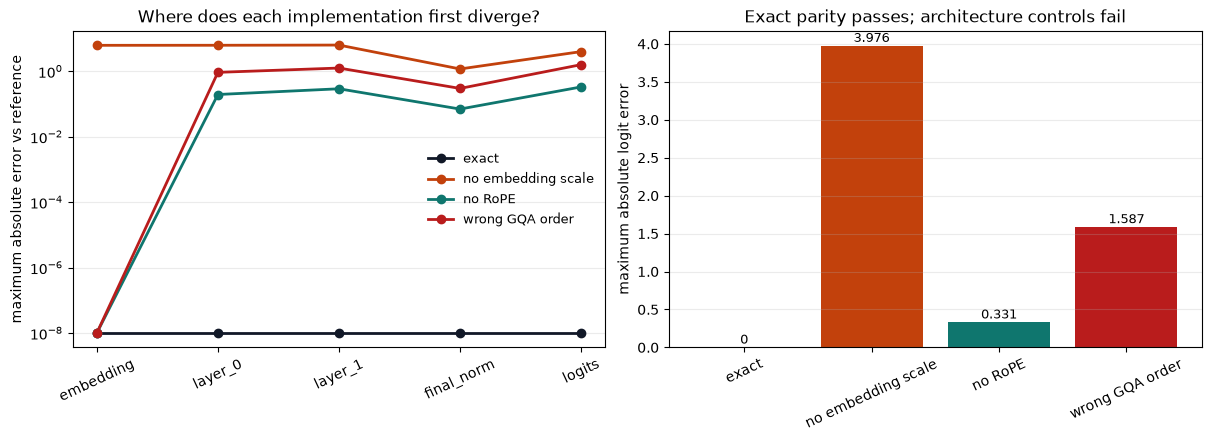

stage              exact max abs error
embedding          0.000e+00
layer_0            0.000e+00
layer_1            0.000e+00
final_norm         0.000e+00
logits             0.000e+00

control             final logit max abs error
no embedding scale   3.975505
no RoPE              0.331010
wrong GQA order      1.587224


In [12]:
signature = run_architecture_controls()
profiles = signature["profiles"]
stages = list(profiles["exact"])
colors = {
    "exact": "#111827",
    "no embedding scale": "#c2410c",
    "no RoPE": "#0f766e",
    "wrong GQA order": "#b91c1c",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), constrained_layout=True)
for name, profile in profiles.items():
    values = [max(profile[stage]["max_abs"], 1e-8) for stage in stages]
    axes[0].plot(stages, values, marker="o", linewidth=2, label=name, color=colors[name])
axes[0].set_yscale("log")
axes[0].set_ylabel("maximum absolute error vs reference")
axes[0].set_title("Where does each implementation first diverge?")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(frameon=False, fontsize=9)

names = list(profiles)
final_errors = [profiles[name]["logits"]["max_abs"] for name in names]
bars = axes[1].bar(names, final_errors, color=[colors[name] for name in names])
axes[1].set_ylabel("maximum absolute logit error")
axes[1].set_title("Exact parity passes; architecture controls fail")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25)
for bar, value in zip(bars, final_errors):
    label = "0" if value == 0 else f"{value:.3f}"
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.05, label, ha="center", fontsize=9)

figure_path = assets_dir / "gemma_parity_signature.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("stage              exact max abs error")
for stage in stages:
    print(f"{stage:18s} {profiles['exact'][stage]['max_abs']:.3e}")
print("\ncontrol             final logit max abs error")
for name in names[1:]:
    print(f"{name:20s} {profiles[name]['logits']['max_abs']:.6f}")

<details><summary>Expected output</summary>

```text
embedding          0.000e+00
layer_0            0.000e+00
layer_1            0.000e+00
final_norm          0.000e+00
logits              0.000e+00

no embedding scale 3.975505
no RoPE             0.331010
wrong GQA order     1.587224
```

Small last-digit differences across PyTorch builds are acceptable. Exact-stage errors must stay below `5e-6`; every control must exceed `1e-2` at the logits.

<details><summary>Interpreting the result</summary>

The exact trace is the signature result: matching only the logits could hide offsetting mistakes, while matching every residual-stream stage pins down the implementation. The controls explain the plot. Embedding scaling diverges immediately; RoPE and GQA first affect the residual stream inside block 0. All three remain visibly wrong at the final logits.

</details>

<details><summary>Help</summary>

If the exact line rises first at `embedding`, inspect the `sqrt(hidden_size)` scale. If it rises at `layer_0`, test RoPE pair order, contiguous KV repetition, masking, and residual updates in that order. If activations match through `final_norm` but logits differ, inspect weight tying and the LM head.

</details>

<details><summary>Solution</summary>

The completed solution notebook should report zero maximum absolute error at every exact stage. Use the first nonzero stage rather than changing tolerances: a tolerance increase cannot repair a wrong convention.

</details>

## Try It Yourself

Change the seven token IDs in `play_input_ids`, rerun the cell, and look for an input where the no-RoPE and wrong-GQA controls swap order. Keep all IDs between 0 and 30. The exact implementation should remain at zero for every valid input.

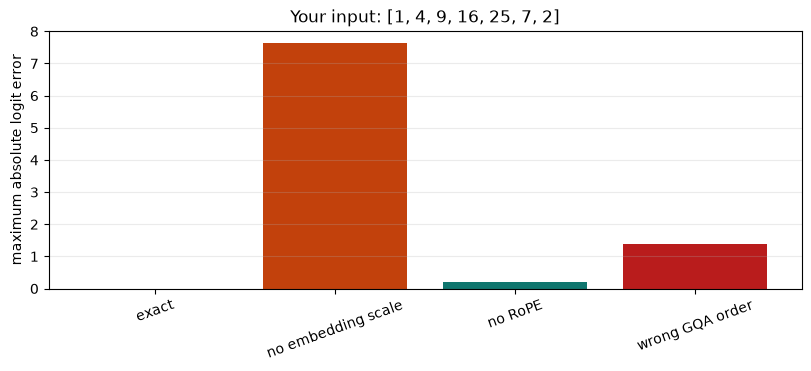

In [13]:
# Try It Yourself: change only these token IDs, keeping values in [0, 30].
play_input_ids = t.tensor([[1, 4, 9, 16, 25, 7, 2]], dtype=t.long, device=DEVICE)
play = run_architecture_controls(play_input_ids)

fig, ax = plt.subplots(figsize=(8, 3.6), constrained_layout=True)
play_names = list(play["profiles"])
play_errors = [play["profiles"][name]["logits"]["max_abs"] for name in play_names]
ax.bar(play_names, play_errors, color=[colors[name] for name in play_names])
ax.set_ylabel("maximum absolute logit error")
ax.set_title(f"Your input: {play_input_ids.squeeze(0).tolist()}")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
plt.show()

### Exercise - bonus anomaly hunt: find the first divergent stage

> **Difficulty:** easy  
> **Suggested time:** 5-10 minutes

Write a small diagnostic that scans a parity profile in execution order and returns the first stage whose maximum absolute error exceeds a tolerance. Use it to verify the predicted control locations.

<details><summary>Expected output</summary>

```text
{'exact': None, 'no embedding scale': 'embedding', 'no RoPE': 'layer_0', 'wrong GQA order': 'layer_0'}
```

</details>

<details><summary>Help</summary>

Python dictionaries preserve insertion order. Return `None` if no stage crosses the tolerance.

</details>

<details><summary>Interpretation</summary>

The first divergent stage is more actionable than the largest final error. It points to the earliest violated contract, before later residual updates propagate the difference.

</details>

<details><summary>Solution</summary>

```python
def first_divergent_stage(
    profile: dict[str, dict[str, float]],
    *,
    tolerance: float = 1e-6,
) -> str | None:
    return next(
        (stage for stage, metrics in profile.items() if metrics["max_abs"] > tolerance),
        None,
    )
```

</details>

In [14]:
def first_divergent_stage(
    profile: dict[str, dict[str, float]],
    *,
    tolerance: float = 1e-6,
) -> str | None:
    return next(
        (stage for stage, metrics in profile.items() if metrics["max_abs"] > tolerance),
        None,
    )



expected_first_divergence = {
    "exact": None,
    "no embedding scale": "embedding",
    "no RoPE": "layer_0",
    "wrong GQA order": "layer_0",
}
observed_first_divergence = {
    name: first_divergent_stage(profile)
    for name, profile in signature["profiles"].items()
}
assert observed_first_divergence == expected_first_divergence
observed_first_divergence

{'exact': None,
 'no embedding scale': 'embedding',
 'no RoPE': 'layer_0',
 'wrong GQA order': 'layer_0'}

## Connection to the public Hugging Face implementation

The repository pins `transformers` in `uv.lock`. The next CPU cell constructs the public `transformers.GemmaForCausalLM` class, copies all 21 deterministic tiny-model weights into your model, and compares logits. This is a real reference-implementation connection with a pinned software environment and exactly matched weights. It is not a pretrained checkpoint result.

In [15]:
import transformers
from transformers import GemmaConfig as HFGemmaConfig
from transformers import GemmaForCausalLM as HFGemmaForCausalLM

local_config = make_tiny_gemma_config()
hf_config = HFGemmaConfig(
    vocab_size=local_config.vocab_size,
    hidden_size=local_config.hidden_size,
    intermediate_size=local_config.intermediate_size,
    num_hidden_layers=local_config.num_hidden_layers,
    num_attention_heads=local_config.num_attention_heads,
    num_key_value_heads=local_config.num_key_value_heads,
    head_dim=local_config.head_dim,
    max_position_embeddings=local_config.max_position_embeddings,
    rope_theta=local_config.rope_theta,
    rms_norm_eps=local_config.rms_norm_eps,
    attention_bias=local_config.attention_bias,
    pad_token_id=0,
    bos_token_id=1,
    eos_token_id=2,
    tie_word_embeddings=local_config.tie_word_embeddings,
)
t.manual_seed(5101)
hf_reference = HFGemmaForCausalLM(hf_config).to(DEVICE).eval()
hf_learner = GemmaForCausalLM(local_config).to(DEVICE).eval()
hf_learner.load_state_dict(hf_reference.state_dict())
hf_input_ids = t.tensor([[1, 5, 8, 13, 2]], device=DEVICE)
with t.inference_mode():
    hf_logits = hf_reference(input_ids=hf_input_ids, use_cache=False).logits
    learner_logits = hf_learner(hf_input_ids, use_cache=False).logits
hf_delta = learner_logits - hf_logits
hf_max_abs = hf_delta.abs().max().item()
hf_mse = hf_delta.square().mean().item()
hf_top5_agreement = (
    learner_logits.topk(5, dim=-1).indices == hf_logits.topk(5, dim=-1).indices
).float().mean().item()
assert hf_max_abs <= 5e-4 and hf_mse <= 1e-7 and hf_top5_agreement == 1.0
print("transformers version:", transformers.__version__)
print("state-dict keys loaded:", len(hf_reference.state_dict()))
print(f"max abs logit error: {hf_max_abs:.8f}")
print(f"logit MSE: {hf_mse:.3e}")
print(f"ordered top-5 agreement: {hf_top5_agreement:.3f}")

W0904 16:38:14.605000 637269 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0904 16:38:14.617000 637269 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


transformers version: 5.12.1
state-dict keys loaded: 21
max abs logit error: 0.00006881
logit MSE: 5.348e-10
ordered top-5 agreement: 1.000


<details><summary>Expected output</summary>

```text
state-dict keys loaded: 21
max abs logit error: approximately 6.9e-05
logit MSE: approximately 5.35e-10
ordered top-5 agreement: 1.000
```

</details>

<details><summary>Interpretation</summary>

The independent local reference is bitwise equal because it uses the same explicit operations. Hugging Face may choose numerically different kernels, so its result is tolerance parity rather than bitwise identity. Agreement of all 21 weights and the ordered top five logits is strong evidence for this architecture subset.

</details>

## Limitations

- The model organism has random deterministic weights and token IDs, so it tests architecture semantics rather than language ability.
- This notebook covers the Gemma conventions represented by `GemmaConfig` here. Later Gemma generations add architecture details outside this section.
- The Hugging Face comparison instantiates the real public class but does not download or claim a gated pretrained Gemma checkpoint.
- CPU execution does not validate CUDA kernels or memory use; the parent verification pass handles serialized GPU checks.

## Reading links

- [Gemma: Open Models Based on Gemini Research and Technology](https://arxiv.org/abs/2403.08295)
- [Hugging Face Gemma model documentation](https://huggingface.co/docs/transformers/model_doc/gemma)
- [RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864)
- [GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints](https://arxiv.org/abs/2305.13245)

The next useful experiment is the anomaly hunt above: alter one line of your own implementation, rerun the trace, and predict the first stage that will move before looking at the plot.